In [1]:
from pymongo import MongoClient
import pandas as pd 
from matplotlib import pyplot as plt

In [3]:
client = MongoClient('mongodb://localhost:27017/')

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales: {collection.count_documents({}):,}")

total sales: 5,000


# Q13: What is the average transaction value for each store location?

In [12]:
#code for Query 13
from pprint import pprint 

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": {
                "store" :"$storeLocation",
                "transaction": "$_id"
        },
        
            "Transaction_Value": {
                "$sum": {
                    "$multiply": [
                            {"$toDouble": "$items.price"},
                            "$items.quantity"
                    ]
                }
            }
        }
    },
    {
        "$group": {
                "_id": "$_id.store",
                "Average_Transaction_Value": {
                    "$avg": "$Transaction_Value"
                }
        }
    },
    {
        "$sort": {"Average_Transaction_Value": -1}
    }
]

avg = list(collection.aggregate(pipeline))
pprint(avg)

avg_df = pd.DataFrame(avg)

avg_df.rename(columns={"_id":"Store Location","Average_Transaction_Value": "Average Transaction Value"}, inplace = True)

avg_df



[{'Average_Transaction_Value': 2138.4661390532547, '_id': 'Austin'},
 {'Average_Transaction_Value': 2028.0630538922155, '_id': 'New York'},
 {'Average_Transaction_Value': 1993.7868891687658, '_id': 'London'},
 {'Average_Transaction_Value': 1989.3718606701939, '_id': 'Seattle'},
 {'Average_Transaction_Value': 1944.7548265895955, '_id': 'San Diego'},
 {'Average_Transaction_Value': 1885.7391349257584, '_id': 'Denver'}]


,Store Location,Average Transaction Value
0,Austin,2138.466139
1,New York,2028.063054
2,London,1993.786889
3,Seattle,1989.371861
4,San Diego,1944.754827
5,Denver,1885.739135


## Code for Visualization

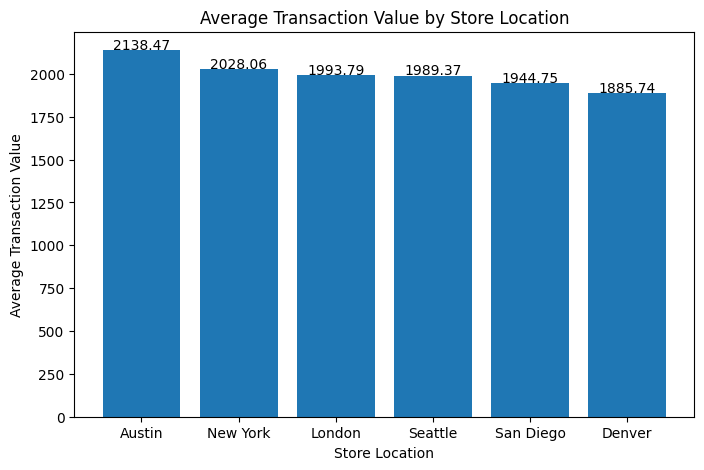

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_df["Store Location"],
    avg_df["Average Transaction Value"]
)

plt.title("Average Transaction Value by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Average Transaction Value")

for i, value in enumerate(avg_df["Average Transaction Value"]):
    plt.text(i, value + 5, f"{value:.2f}", ha='center')

plt.show()